# Titanic: Explorative Data Analysis (Python)

This notebook loads the Titanic dataset from a **raw GitHub CSV** and walks through an exploratory analysis.

- Dataset source (raw CSV): `datasciencedojo/datasets` repository.
- Check (and add?) profiling report!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
t_df = pd.read_csv(url)
# t_df.info()

# Transform to categorical vars:
cats = ["Survived", "Pclass", "Sex", "Embarked"]
for c in cats:
    t_df[c] = t_df[c].astype('category')

print(t_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB
None


<Axes: xlabel='Sex'>

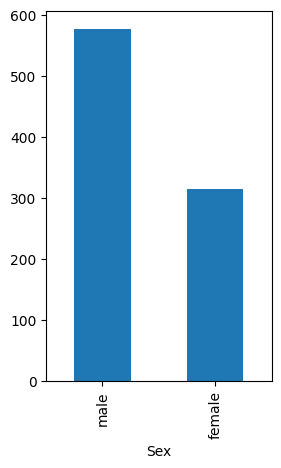

In [6]:
# Plot Titanic Survival by Gender
plt.subplot(1,2,1)

t_df["Sex"].value_counts().plot(kind = "bar")

<positron-console-cell-15>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


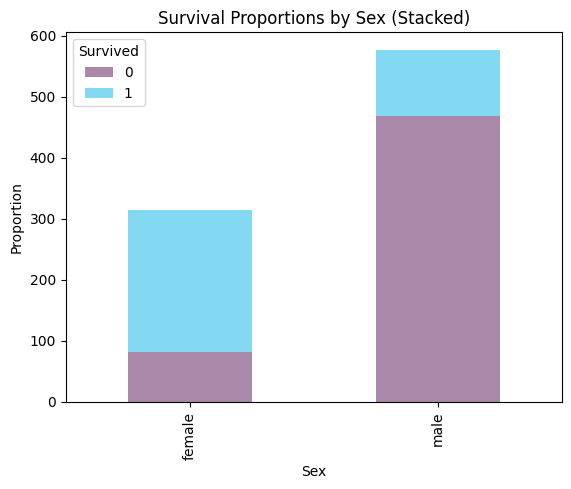

In [15]:
t_df.groupby("Sex")["Survived"].value_counts().unstack().plot(kind='bar', stacked=True, color=["#a988A9", "#83d9f1"])
plt.ylabel('Proportion')
plt.xlabel('Sex')
plt.title("Survival Proportions by Sex (Stacked)")
plt.show()

<positron-console-cell-11>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


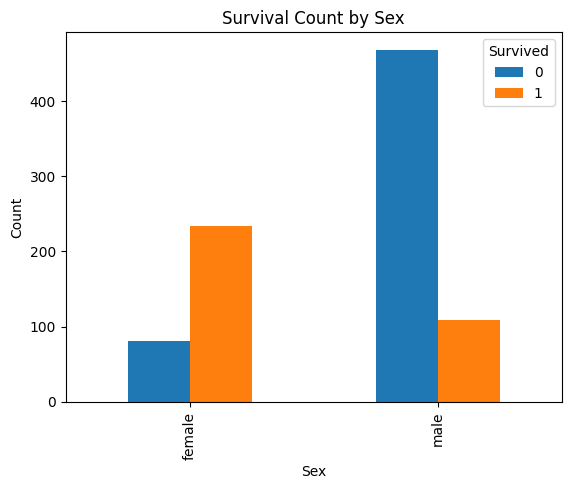

In [11]:
t_df.groupby('Sex')['Survived'].value_counts().unstack().plot(kind='bar')
plt.ylabel('Count')
plt.xlabel('Sex')
plt.title('Survival Count by Sex')
plt.show()

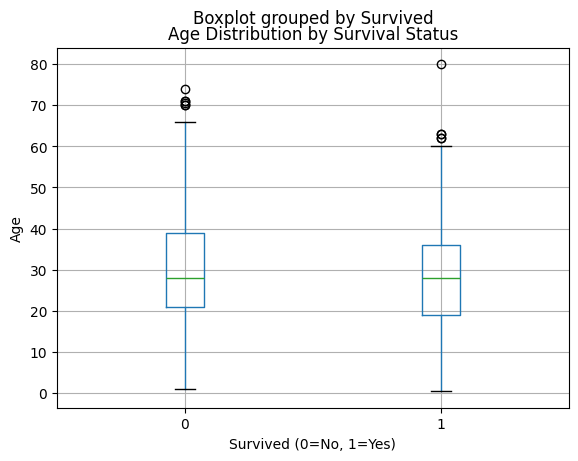

In [12]:
# Create boxplot of Age by Survived category
t_df.boxplot(column='Age', by='Survived')
plt.ylabel('Age')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.title('Age Distribution by Survival Status')
plt.show()

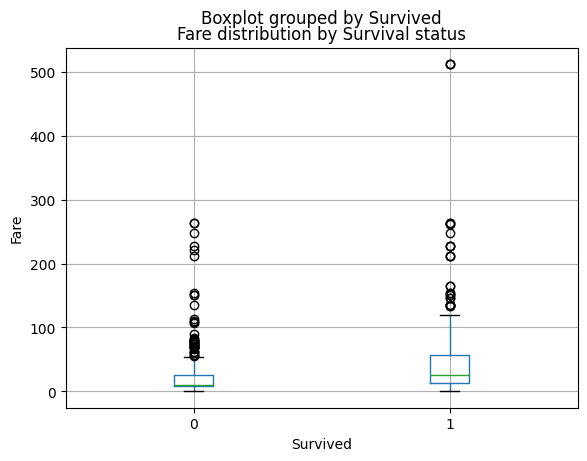

In [16]:
# Box by fare
t_df.boxplot(column="Fare", by="Survived")
plt.ylabel("Fare")
plt.xlabel("Survived")
plt.title("Fare distribution by Survival status")
plt.show()

In [ ]:
# Supervised Segmentation Example
# Splitting passengers by Sex and Class

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Clean the data first - handle missing values
titanic_clean = t_df.copy()
titanic_clean['Age'].fillna(titanic_clean['Age'].median(), inplace=True)
titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0], inplace=True)
titanic_clean = titanic_clean.dropna(subset=['Fare'])

# Prepare features for the decision tree
features = ['Sex', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X = titanic_clean[features].copy()

# Convert categorical variables to numeric
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
y = titanic_clean['Survived']

# Build decision tree with similar parameters to R version
tree_model = DecisionTreeClassifier(
    criterion='gini',           # similar to method="class" in R
    min_samples_split=10,       # equivalent to minsplit=20
    min_samples_leaf=10,        # equivalent to minbucket=10
    ccp_alpha=0.01,             # similar to cp=0.02
    random_state=42
)

tree_model.fit(X, y)

<positron-console-cell-13>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<positron-console-cell-13>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

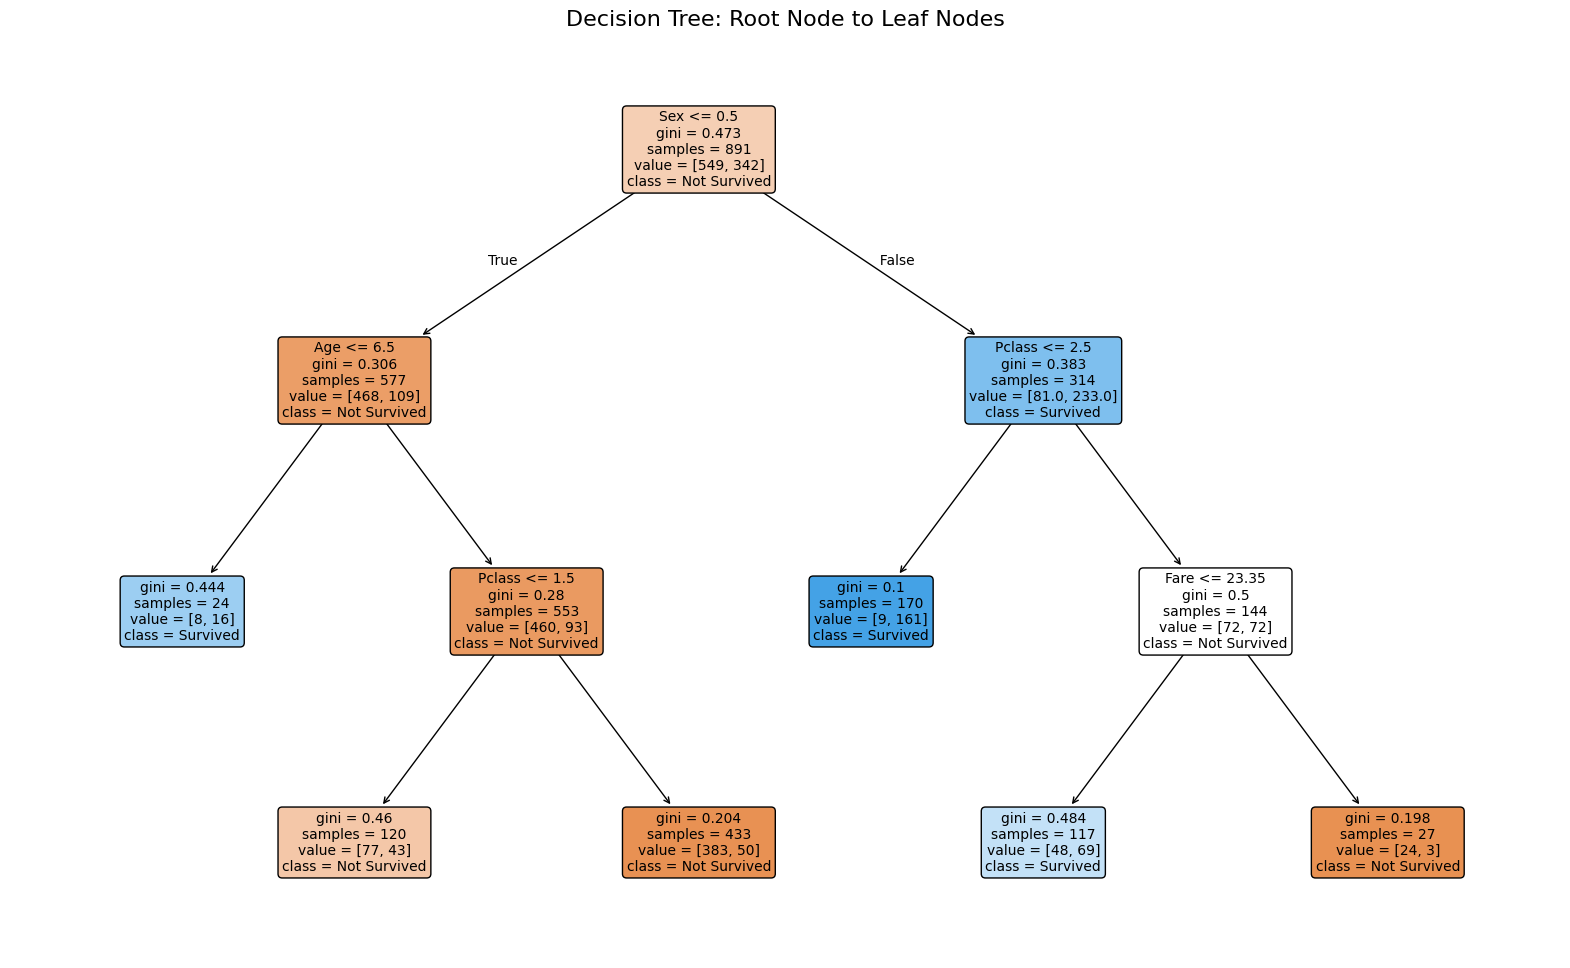

In [14]:
# Create visualization
plt.figure(figsize=(20, 12))
plot_tree(tree_model, 
          feature_names=['Sex', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'],
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree: Root Node to Leaf Nodes", fontsize=16)
plt.show()